# ex02) 오차 역전파 - MNIST 손글씨 다중분류

> **한 줄 요약** : 순전파로 예측하고, **역전파로 오차를 되돌려 보내며 가중치를 학습**한다.
> 그리고 다중분류는 `softmax` + `categorical_crossentropy` + `원핫인코딩` 3종 세트가 필수!

## 오늘의 흐름
| 단계 | 내용 |
|---|---|
| 1 | 오차 역전파 개념 (순전파 vs 역전파) |
| 2 | 활성화 함수 / sigmoid의 한계 (기울기 손실) |
| 3 | MNIST 데이터 불러오기 & 탐색 |
| 4 | MLP 신경망 설계 (Flatten + Dense + softmax) |
| 5 | 원핫인코딩 후 학습 |
| 6 | 결과 시각화 및 분석 |

## 꼭 기억할 키워드
`순전파` `역전파` `기울기 손실(Vanishing Gradient)` `Flatten` `softmax` `categorical_crossentropy` `원핫인코딩`


# 1. 오차 역전파 (Back Propagation)

딥러닝이 "학습"한다는 말의 실체 = **순전파 → 오차 계산 → 역전파 → 가중치 수정**의 반복

| 구분 | 방향 | 하는 일 |
|---|---|---|
| **순전파 (Forward)** | 입력층 → 출력층 | 데이터를 통과시켜 결과를 **예측**한다 (계산) |
| **역전파 (Backward)** | 출력층 → 입력층 | 출력층에서 생긴 **오차를 거꾸로 전파**하며 가중치(w)를 **수정**한다 (학습) |

- 순전파 : 입력 데이터를 입력층에서 출력층까지 정방향으로 이동시키며 출력값을 '예측'하는 과정
  - 👉 계산하여 예측하는 과정
- 오차역전파(역전파) : 출력층에서 발생한 오차를 입력층으로 전파시키면서 최적의 결과를 구하기 위해 가중치에 대해 학습해 나가는 과정
  - 👉 최적의 방향으로 학습하는 과정

> **핵심** : 오차를 w로 미분(기울기)해서, 오차가 줄어드는 방향으로 w를 조금씩 밀어준다.


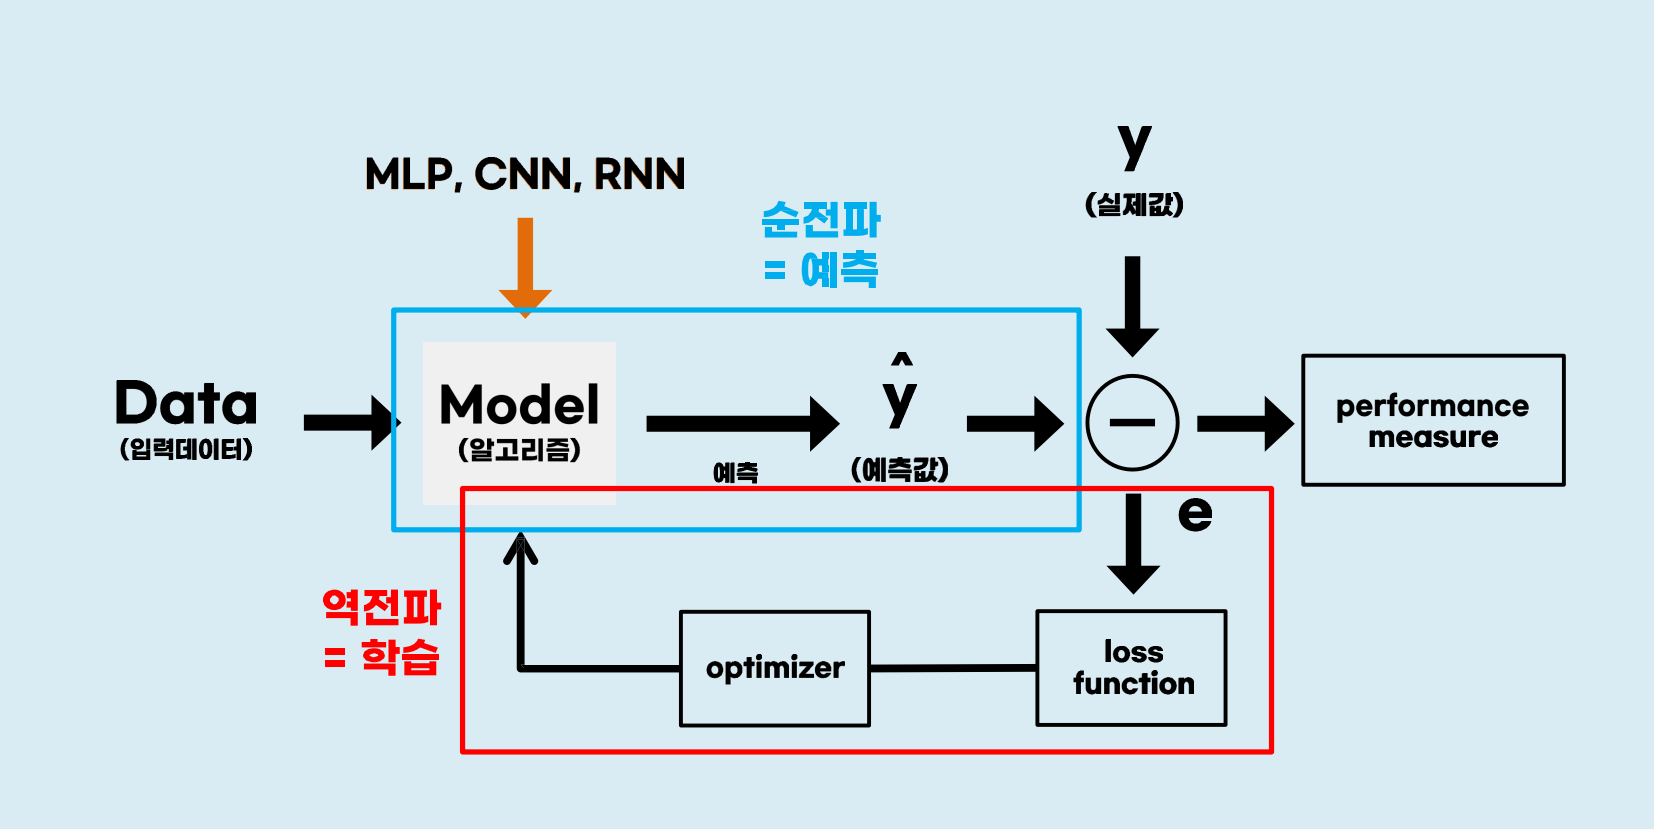

## 2. 활성화 함수 (Activation Function)

- 사람처럼 사고하고 행동할 수 있도록 인공지능 기술을 실현하기 위해 도입된 기술
- 특정 수치(**역치**) 이상의 값만 다음 층으로 전달하도록 설정하는 기능
  - 뉴런이 "충분히 자극받았을 때만 신호를 넘긴다"는 것을 흉내낸 것
- 딥러닝 신경망은 **선형모델(y = wx + b)** 을 쌓아 만든다
  - 선형 + 선형 = 여전히 선형 → 층을 아무리 쌓아도 직선밖에 못 그림 ❌
  - 그래서 층 사이에 **비선형 활성화 함수**를 끼워 넣어야 비선형 문제도 풀 수 있다 ✅
- 이런 이유로 처음 도입된 비선형 활성화 함수가 **sigmoid**


### 2-1. Sigmoid의 문제점

- 역전파는 **미분값(기울기)** 을 이용해 w를 수정한다
- 그런데 sigmoid를 미분하면 최댓값이 **0.25** 밖에 안 된다
- 층을 통과할 때마다 0.25 이하가 계속 곱해짐 → 기울기가 점점 **0에 수렴**
- 결과적으로 앞쪽(입력층 근처) 층은 거의 학습이 안 되어 최적의 w를 찾기 어렵다
  - 👉 이것이 **기울기 손실(Vanishing Gradient)**


### 2-2. 기울기 손실 (Vanishing Gradient)

- 오차를 개선하기 위해 미분을 통해 최적의 w값을 찾는데, 딥러닝 층이 **깊어질수록** 과거의 층(입력층 쪽)이 반응하지 못하는 문제
- sigmoid는 미분값이 너무 작아 기울기 손실이 쉽게 발생한다

**이를 해결하기 위해 등장한 활성화 함수들**

| 함수 | 특징 |
|---|---|
| `tanh` (하이퍼볼릭 탄젠트) | 출력 범위 -1 ~ 1, sigmoid보다 기울기가 큼 |
| `relu` (렐루) | 음수는 0, 양수는 그대로 → 기울기 손실이 거의 없음, **가장 많이 사용** |
| `Leaky ReLU` | ReLU의 음수 구간을 0이 아닌 아주 작은 값으로 살려둔 버전 |


## 3. 오늘의 목표

- 0~9까지 숫자를 쓴 손글씨 이미지 데이터(MNIST)를 가져와 **어떤 숫자인지 예측**하는 모델 만들기
- **다중분류** 문제이므로 이진분류와 달라지는 부분을 꼭 체크하기
  - 출력층 `activation` → `softmax`
  - `loss` → `categorical_crossentropy`
  - 정답 데이터 → **원핫인코딩** 필요
- 이미지 데이터를 사용 (다차원 데이터 다루는 법 연습)


### 3-1. 이미지 데이터 구조

- 컴퓨터는 이미지를 그대로 이해할 수 없으므로 **숫자로 변환**해서 사용해야 한다
- 이미지를 이루는 가장 작은 단위인 **픽셀(pixel)** 단위로 쪼개고, 각 픽셀의 색상을 수치로 변환

| 이미지 종류 | 차원 | 형태 |
|---|---|---|
| **컬러 이미지** | 3차원 | (세로픽셀 수, 가로픽셀 수, RGB 색상정보) |
| **흑백 이미지** | 2차원 | (세로픽셀 수, 가로픽셀 수) |

> MNIST는 흑백(28 x 28) → 픽셀값 **0(검정) ~ 255(흰색)**


### 3-2. 다중분류 (Multi-class Classification)

- **다중분류** : 분류해야 하는 클래스(정답의 종류)가 3개 이상인 문제
- 다중분류 모델의 **출력층 구조**
  - `units` : 클래스의 개수(정답의 종류) → MNIST는 **10**
  - `activation` : **`softmax`**
- **softmax** : 각 클래스에 대한 **확률값**을 출력하는 함수, 모든 확률의 합 = **1**
  - 예) `[0.01, 0.02, 0.9, ... ]` → 가장 큰 값의 위치가 예측한 정답
- sigmoid에 비해 오차의 평균을 줄여주기 때문에 다중분류에서 사용한다

| 구분 | 출력층 units | 출력층 activation | loss |
|---|---|---|---|
| 이진분류 | 1 | `sigmoid` | `binary_crossentropy` |
| 다중분류 | 클래스 개수 | `softmax` | `categorical_crossentropy` |


In [11]:
# 데이터 분석 3종 세트 불러오기
import numpy as np              # 수치 계산 / 배열 다루기
import pandas as pd             # 표 형태 데이터 다루기 (원핫인코딩에 사용)
import matplotlib.pyplot as plt # 시각화 (이미지 확인 + 학습 결과 그래프)


## 4. 데이터 가져오기

- 손글씨가 그려진 이미지 데이터(**MNIST**) 가져오기
- Tensorflow에서 기본 제공하는 데이터셋 사용 → 별도 파일 다운로드 불필요


In [2]:
# 데이터셋을 가져올 수 있는 도구 불러오기
from tensorflow.keras.datasets import mnist

# load_data() : 훈련용 / 테스트용을 이미 나눠서 반환해준다
# 반환 형태 → (X_train, y_train), (X_test, y_test)
# X : 문제(이미지), y : 정답(숫자 라벨)
(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [3]:
# 데이터 크기 확인 (딥러닝은 shape 확인이 제일 중요!)
print(X_train.shape)  # (60000, 28, 28) → 훈련 이미지 6만장, 28x28 크기
print(y_train.shape)  # (60000,)        → 훈련 정답 6만개 (숫자 1개씩)
print(X_test.shape)   # (10000, 28, 28) → 테스트 이미지 1만장
print(y_test.shape)   # (10000,)        → 테스트 정답 1만개

# ※ X는 3차원(장수, 세로, 가로)인데 Dense층은 1차원만 받는다 → 나중에 Flatten 필요!


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [6]:
# 다중분류가 맞는지 / 어떤 라벨로 이루어져 있는지 확인
# np.unique(..., return_counts=True) → (고유값 배열, 각 값의 개수 배열)
np.unique(y_train, return_counts=True)

# [결과 해석]
# 1) 정답 클래스의 개수(정답의 종류) : 10개 (0 ~ 9)  → 다중분류 문제 확정
# 2) 각 숫자별 개수 : 5,400 ~ 6,700 정도로 차이는 조금 있지만 대체로 균등
#    → 한쪽으로 편중된 불균형 데이터가 아니므로 그대로 학습해도 문제없다고 판단


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [8]:
# 데이터 실제 값 확인하기
# 이미지 1장 = 28x28 짜리 숫자 배열
# 0에 가까울수록 검은색, 255에 가까울수록 흰색
X_train[10]


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118,
        219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254,
        254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

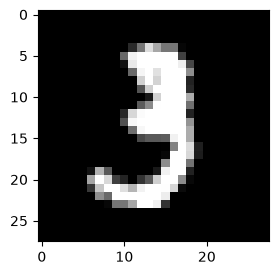

In [12]:
# 데이터가 진짜 이미지인지 눈으로 확인 (시각화)
plt.figure(figsize=(3,3))            # 그림 크기 지정
plt.imshow(X_train[10], cmap='gray') # cmap='gray' : 흑백으로 그리기
plt.show()


In [13]:
# 정답 데이터 확인
# 눈으로 봤을 때 숫자가 3으로 보이므로, 정답도 3인지 대조해본다
y_train[10]


np.uint8(3)

## 5. MLP 신경망 설계

- 다중분류를 위한 인공 신경망(MLP, 다층 퍼셉트론) 설계
- 0~9 까지의 손글씨 숫자 이미지를 분류하는 모델 만들기

**신경망 만드는 4단계 (항상 동일)**
1. 뼈대 생성 (`Sequential`)
2. 입력층 쌓기 (`InputLayer`)
3. 중간층 쌓기 (`Dense`)
4. 출력층 쌓기 (`Dense`)
→ 이후 `compile`(학습방법 설정) → `fit`(학습)


### 5-1. MLP층(Dense)을 사용할 때 주의점 ⚠️

- 이미지 데이터나 시계열 데이터 같은 **다차원 데이터**는 `Dense`층에 그대로 넣을 수 없다
  - `Dense`층은 **1차원 데이터만** 학습/예측 가능
- 따라서 다차원 → **1차원으로 변형**해서 사용해야 한다

| 방법 | 설명 |
|---|---|
| `reshape()` | 내가 직접 데이터 모양을 바꿔주는 방법 |
| `Flatten()` 층 | 모델 안에서 자동으로 1차원으로 펴주는 방법 (편함 👍) |

> (28, 28) → **Flatten** → (784, )


In [ ]:
# [참고] reshape 를 직접 사용하는 방법
# (60000, 28, 28) → (60000, 28*28) = (60000, 784)
# X_train = X_train.reshape(60000, 28*28)

# 이번 실습에서는 아래처럼 Flatten 층을 사용하므로 이 방법은 쓰지 않는다.


In [21]:
# 신경망 설계를 하기 위한 도구 불러오기
from tensorflow.keras.models import Sequential   # 뼈대(모델 틀)를 만들어주는 도구
from tensorflow.keras.layers import Dense        # 중간층/출력층을 쌓는 도구 (전결합층)
from tensorflow.keras.layers import InputLayer   # 입력층을 쌓는 도구
from tensorflow.keras.layers import Flatten      # 다차원 → 1차원으로 펴주는 도구

# Flatten : 값을 버리지 않고(데이터 손실 없이) 모양만 일렬로 펴준다


In [22]:
# 신경망 설계

# 1. 뼈대 생성 (층을 순서대로 쌓겠다는 선언)
model1 = Sequential()

# 2. 입력층 쌓기 - 들어올 데이터 한 개의 크기를 알려준다
#    이미지 1장의 크기 = (28, 28)  ※ 6만장의 '6만'은 적지 않는다!
model1.add(InputLayer(shape = (28, 28)))

# Dense층은 1차원만 받으므로 (28,28) → (784,) 로 펴주기
model1.add(Flatten())

# 3. 중간층(은닉층) 쌓기 - units는 퍼셉트론(뉴런) 개수
model1.add(Dense(units = 64,  activation = 'sigmoid'))
model1.add(Dense(units = 128, activation = 'sigmoid'))
model1.add(Dense(units = 64,  activation = 'sigmoid'))

# 4. 출력층 쌓기 ★다중분류 핵심★
#    units = 10       → 정답의 종류(0~9)만큼
#    activation = softmax → 10개 클래스의 확률값으로 출력 (합 = 1)
model1.add(Dense(units = 10, activation = 'softmax'))


In [24]:
# 학습방법 및 평가방법 설정 (compile)
model1.compile(
    loss = 'categorical_crossentropy',  # 오차를 재는 자 → 다중분류이므로 categorical
    optimizer = 'SGD',                  # 오차를 줄이는 방법(최적화 함수)
    metrics = ['accuracy']              # 사람이 보기 위한 평가지표 (정확도)
)

# [loss 정리]
# 이진분류 : binary_crossentropy
# 다중분류 : categorical_crossentropy       (정답이 원핫인코딩 되어 있을 때)
# 회귀     : mean_squared_error


### 5-2. 다중분류 모델을 사용할 때 주의할 점 ⚠️

- 출력층에 `softmax`를 사용하므로 모델의 **예측값은 10개짜리 확률 배열**로 나온다
  - 예) `[0.01, 0.00, 0.02, 0.93, ...]`
- 그런데 우리가 가진 **실제 정답은 `3` 처럼 정수 1개**
- 예측값과 정답의 **형태가 달라** 학습 시 오류가 발생한다 ❌
- 그래서 정답도 같은 모양으로 바꿔줘야 한다 → **원핫인코딩(One-Hot Encoding)**

```
정답 3  →  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
```


In [23]:
# 정답 데이터 원핫인코딩 진행
# pd.get_dummies() : 각 클래스를 열(column)로 만들어 해당하는 곳만 1, 나머지는 0
# dtype=int : True/False 대신 1/0 으로 받기
y_train_one_hot = pd.get_dummies(y_train, dtype = int)  # (60000,) → (60000, 10)
y_test_one_hot  = pd.get_dummies(y_test,  dtype = int)  # (10000,) → (10000, 10)


In [26]:
# 학습 진행
his1 = model1.fit(
    X_train, y_train_one_hot,  # 문제(이미지), 정답(원핫인코딩된 것)
    epochs = 80,               # 전체 데이터를 80번 반복 학습
    validation_split = 0.2     # 훈련데이터의 20%를 검증용으로 떼어놓고 매 epoch마다 채점
)

# his1 : 학습 과정(정확도/오차 기록)이 담긴 History 객체 → 아래에서 그래프로 그린다
# 출력의 accuracy = 훈련 정확도 / val_accuracy = 검증 정확도


Epoch 1/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2734 - loss: 2.2334 - val_accuracy: 0.4377 - val_loss: 2.1307
Epoch 2/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5334 - loss: 1.9022 - val_accuracy: 0.6058 - val_loss: 1.6104
Epoch 3/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6931 - loss: 1.3431 - val_accuracy: 0.7696 - val_loss: 1.1070
Epoch 4/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7824 - loss: 0.9595 - val_accuracy: 0.8316 - val_loss: 0.8117
Epoch 5/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8364 - loss: 0.7273 - val_accuracy: 0.8625 - val_loss: 0.6276
Epoch 6/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8586 - loss: 0.6014 - val_accuracy: 0.8687 - val_loss: 0.5479
Epoch 7/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8704 - loss: 0.5184 - val_accuracy: 0.8810 - val_loss: 0.4819
Epoch 8/80
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8759 - loss: 0.4789 - 

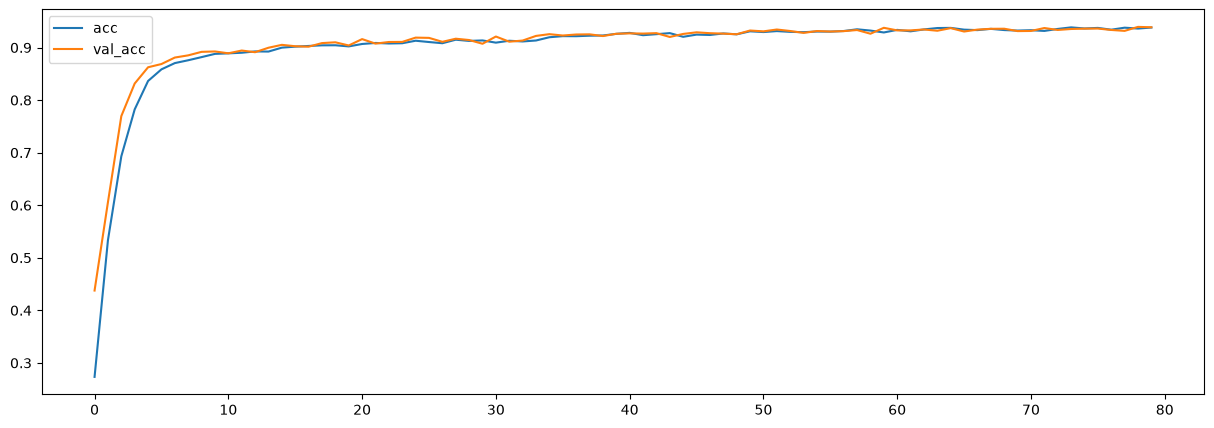

In [27]:
# 학습 결과 시각화 (과대적합 여부 확인)
plt.figure(figsize=(15,5))
plt.plot(his1.history['accuracy'],     label = 'acc')      # 훈련 정확도
plt.plot(his1.history['val_accuracy'], label = 'val_acc')  # 검증 정확도
plt.legend()
plt.show()

# [보는 법]
# 두 선이 붙어서 같이 올라간다 → 학습이 잘 되고 있음 (이번 경우)
# acc는 오르는데 val_acc가 내려간다 → 과대적합(Overfitting)


## 6. 결과 분석 & 오늘의 결론

**결과 : 훈련 정확도 약 0.938 / 검증 정확도 약 0.939 (epochs=80, sigmoid + SGD)**

- activation을 `sigmoid`로 사용했지만 성능이 비교적 좋게 나옴
- sigmoid는 기울기 손실이 잘 일어나 성능이 안 좋게 나올 **가능성이 높은 것은 맞으나, 무조건 낮게 나오는 것은 아니다**
  - MNIST는 비교적 단순한 데이터라 층이 깊지 않으면 sigmoid로도 충분히 학습됨
- 사용하는 데이터에 따라 성능이 좋게 나올 수도 있다
- 👉 결국 딥러닝에서는 **다양한 조합으로 학습하여 최적의 성능을 내는 모델을 찾아내는 것**이 목표
  - 이어지는 **ex03**에서 여러 활성화 함수 + 최적화 함수 조합을 직접 비교해본다
